# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penguins = pd.read_csv("penguins.csv")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
print("Dataset shape:", penguins.shape)

print("\nData types and non-null values:")
penguins.info()

print("\nMissing values:")
print(penguins.isnull().sum())

print("\nDescriptive statistics:")
penguins.describe()

Dataset shape: (344, 7)

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Descriptive statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
penguins_clean = penguins.dropna()

print("Original dataset shape:", penguins.shape)
print("Cleaned dataset shape:", penguins_clean.shape)

print("\nRemaining missing values:")
print(penguins_clean.isnull().sum())

Original dataset shape: (344, 7)
Cleaned dataset shape: (334, 7)

Remaining missing values:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


I chose to remove rows with missing values because there are only a small number of incomplete observations. This allows the analysis to use complete measurements without estimating or changing the original data.

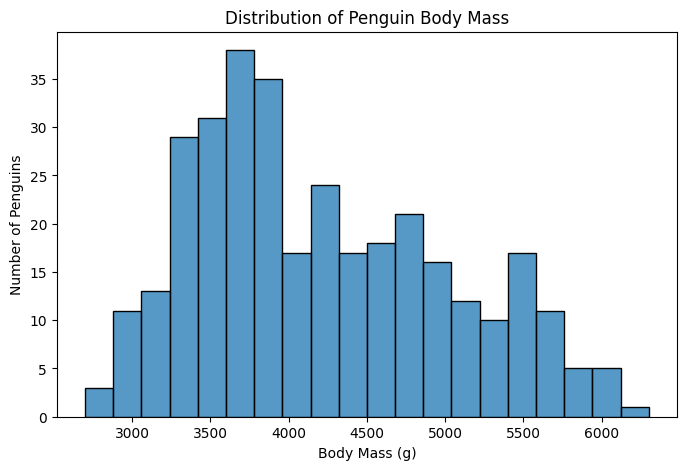

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(data=penguins_clean, x="body_mass_g", bins=20)

plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")
plt.show()

Why this plot?

I used a histogram because it shows how body mass is distributed across the penguins and makes it easy to identify common weight ranges and the overall shape of the distribution.

What it shows:

The body masses are spread across a wide range, with most penguins concentrated in the middle of the distribution. There are fewer penguins at the lowest and highest body masses.

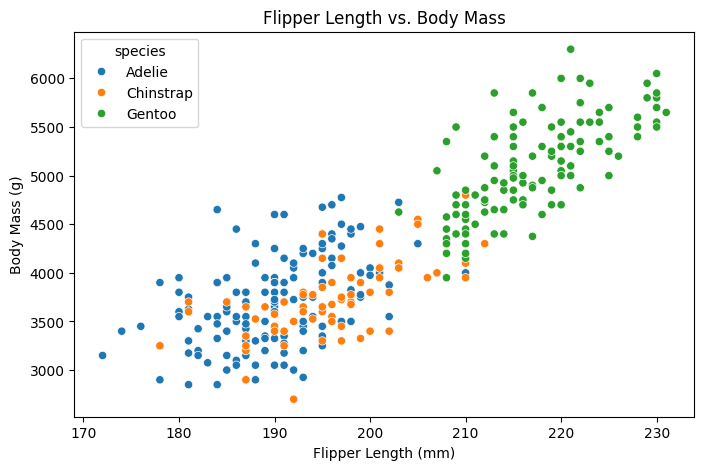

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.title("Flipper Length vs. Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

Why this plot?

I used a scatter plot because it allows me to examine the relationship between flipper length and body mass. Coloring the points by species also allows the species to be compared.

What it shows:

There is a positive relationship between flipper length and body mass. Penguins with longer flippers generally have greater body mass. The species also form noticeable groups in the graph.

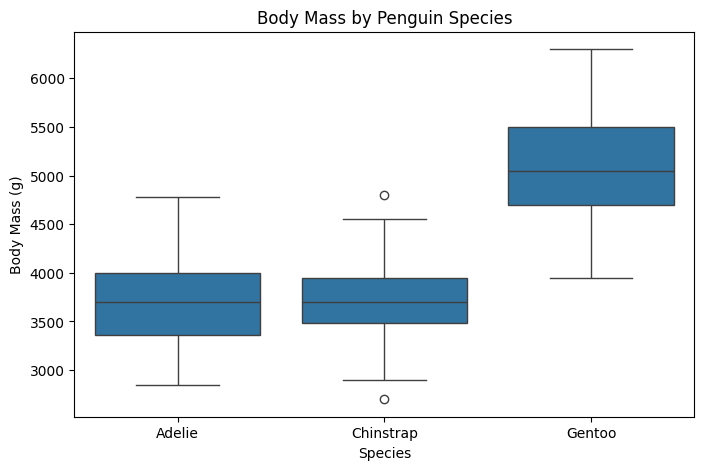

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=penguins_clean,
    x="species",
    y="body_mass_g"
)

plt.title("Body Mass by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

Why this plot?

I used a box plot because it makes it easy to compare the body mass distributions of different penguin species. It also shows the median, spread, and potential outliers.

What it shows:

The three penguin species have different body mass distributions. Gentoo penguins generally have higher body masses than Adelie and Chinstrap penguins. There is also variation within each species.

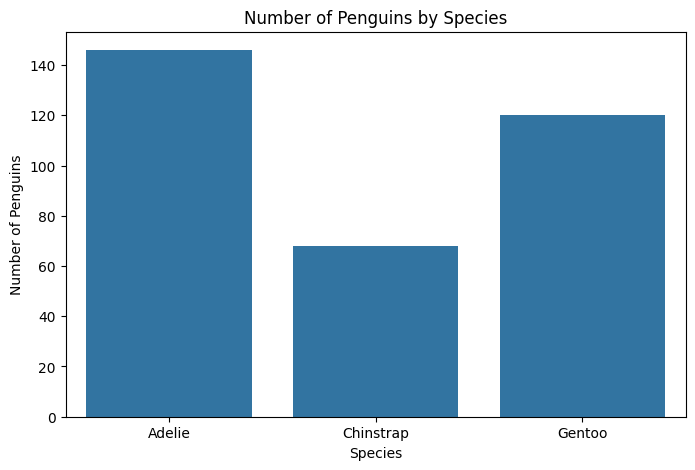

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=penguins_clean,
    x="species"
)

plt.title("Number of Penguins by Species")
plt.xlabel("Species")
plt.ylabel("Number of Penguins")
plt.show()

Why this plot?

I used a bar chart because it is appropriate for comparing the number of observations in each categorical group.

What it shows:

The dataset contains observations from three penguin species. Adelie has the largest number of observations, while Chinstrap has fewer observations than the other species.

In [9]:
print("""
Key Findings:

1. The dataset contains 344 penguins from three different species.
2. A small number of observations contain missing values, so incomplete rows were removed for the analysis.
3. Body mass varies considerably among the penguins.
4. Flipper length and body mass have a positive relationship, meaning penguins with longer flippers generally have greater body mass.
5. Penguin species have noticeably different body mass distributions.
6. The scatter plots show that measurements such as bill length, bill depth, and flipper length can help distinguish between species.
""")


Key Findings:

1. The dataset contains 344 penguins from three different species.
2. A small number of observations contain missing values, so incomplete rows were removed for the analysis.
3. Body mass varies considerably among the penguins.
4. Flipper length and body mass have a positive relationship, meaning penguins with longer flippers generally have greater body mass.
5. Penguin species have noticeably different body mass distributions.
6. The scatter plots show that measurements such as bill length, bill depth, and flipper length can help distinguish between species.

